# Malaysia Grid Emission Factor: 2017–2024

## The Question

Has Malaysia's electricity grid actually gotten cleaner since 2017 — and at what pace? A business counting on grid decarbonization to bring down its own Scope 2 emissions, rather than investing in its own renewable capacity, needs to know whether that bet is actually paying off.

## The Answer

Barely, and unevenly. Peninsular Malaysia's grid emission factor — where the large majority of national demand sits — fell just 3.5% over seven years (2017–2024), and most of that decline is a return from a 2020 outlier peak, not a steady trend: 2021's figure (0.757) is barely below 2017's (0.767). Sabah's grid emission factor actually *rose* slightly over the same window. Only Sarawak, already the cleanest of the three by a wide margin thanks to its hydro-heavy generation mix, shows a real decline — and it started from a very different baseline. A business assuming the grid will meaningfully decarbonize on its own, on this seven-year track record, is not looking at a trend that supports that assumption.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

gef = pd.read_csv('../data/processed/grid_emission_factor.csv')
gef

,year,region,gef_gg_co2e_per_gwh,source_publication,provisional
0,2017,Peninsular,0.767,GEF_2017-2022_20241125,False
1,2017,Sabah,0.530,GEF_2017-2022_20241125,False
2,2017,Sarawak,0.213,GEF_2017-2022_20241125,False
3,2018,Peninsular,0.797,GEF_2017-2022_20241125,False
4,2018,Sabah,0.500,GEF_2017-2022_20241125,False
5,2018,Sarawak,0.193,GEF_2017-2022_20241125,False
6,2019,Peninsular,0.753,GEF_2017-2022_20241125,False
7,2019,Sabah,0.548,GEF_2017-2022_20241125,False
8,2019,Sarawak,0.222,GEF_2017-2022_20241125,False
9,2020,Peninsular,0.821,GEF_2017-2022_20241125,False


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## How much has each region's grid emission factor changed, 2017–2024?

In [3]:
regions = ['Peninsular', 'Sabah', 'Sarawak']
summary = []
for region in regions:
    series = gef[gef['region'] == region].set_index('year')['gef_gg_co2e_per_gwh']
    start, end = series.loc[2017], series.loc[2024]
    total_change = (end / start - 1) * 100
    cagr = ((end / start) ** (1 / 7) - 1) * 100
    summary.append({'region': region, '2017': start, '2024': end,
                     'total_change_pct': round(total_change, 1), 'cagr_pct': round(cagr, 2)})

summary_df = pd.DataFrame(summary).set_index('region')
summary_df

,2017,2024,total_change_pct,cagr_pct
region,,,,
Peninsular,0.767,0.740,-3.5,-0.51
Sabah,0.530,0.539,1.7,0.24
Sarawak,0.213,0.199,-6.6,-0.97


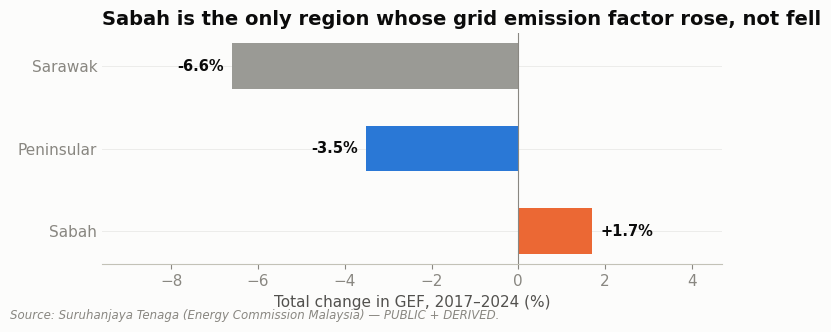

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
region_colors_local = {'Peninsular': ACCENT_1, 'Sabah': ACCENT_2, 'Sarawak': GRAY}
region_order = ['Sabah', 'Peninsular', 'Sarawak']  # sorted by total_change_pct, ascending (least to most decline)
values = [summary_df.loc[r, 'total_change_pct'] for r in region_order]
colors = [region_colors_local[r] for r in region_order]

bars = ax.barh(region_order, values, color=colors, height=0.55, edgecolor='none')
for bar, v in zip(bars, values):
    x = bar.get_width()
    ax.annotate(f'{v:+.1f}%', xy=(x, bar.get_y() + bar.get_height() / 2),
                xytext=(6 if x >= 0 else -6, 0), textcoords='offset points',
                va='center', ha='left' if x >= 0 else 'right',
                fontsize=10.5, fontweight='semibold', color=INK)

ax.axvline(0, color=INK_MUTED, linewidth=0.8)
ax.set_title('Sabah is the only region whose grid emission factor rose, not fell', loc='left')
ax.set_xlabel('Total change in GEF, 2017\u20132024 (%)')
ax.set_xlim(min(values) - 3, max(values) + 3)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

add_source(ax.figure, 'Source: Suruhanjaya Tenaga (Energy Commission Malaysia) \u2014 PUBLIC + DERIVED.')
plt.show()


## Visualizing the trend across all three regions

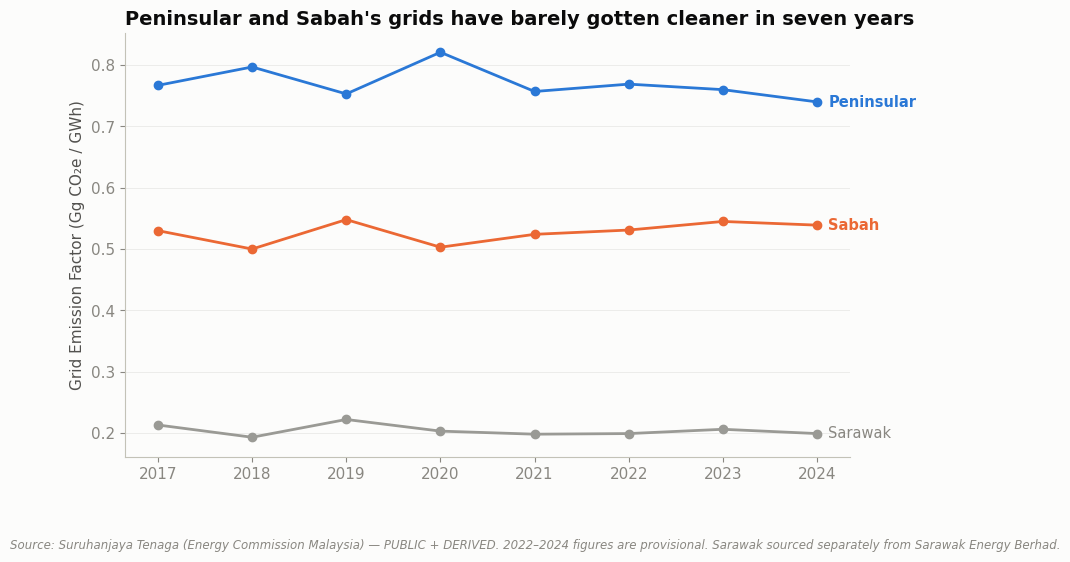

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
region_colors = {'Peninsular': ACCENT_1, 'Sabah': ACCENT_2, 'Sarawak': GRAY}
region_weights = {'Peninsular': 'bold', 'Sabah': 'bold', 'Sarawak': 'normal'}
region_label_colors = {'Peninsular': ACCENT_1, 'Sabah': ACCENT_2, 'Sarawak': INK_MUTED}
for region in regions:
    series = gef[gef['region'] == region].set_index('year')['gef_gg_co2e_per_gwh']
    ax.plot(series.index, series.values, marker='o', markersize=6, linewidth=2,
            color=region_colors[region])
    end_label(ax, series.index[-1], series.values[-1], region,
              region_label_colors[region], weight=region_weights[region])

ax.set_title("Peninsular and Sabah's grids have barely gotten cleaner in seven years", loc='left')
ax.set_ylabel('Grid Emission Factor (Gg CO₂e / GWh)')
ax.set_xlabel('')
fig.subplots_adjust(right=0.85)

add_source(ax.figure, 'Source: Suruhanjaya Tenaga (Energy Commission Malaysia) — PUBLIC + DERIVED. '
                       '2022–2024 figures are provisional. Sarawak sourced separately from Sarawak Energy Berhad.')
plt.show()


## Why is Sarawak so much lower than Peninsular and Sabah to begin with?

Sarawak's grid emission factor (around 0.20 throughout the study window) sits at roughly a quarter of Peninsular Malaysia's (around 0.75–0.82). This gap predates and is unrelated to the 2017–2024 trend being examined here — it reflects Sarawak's generation mix being hydro-dominated (including large-scale hydro schemes such as Bakun), a structural difference from Peninsular and Sabah's coal-and-gas-dominated grids, not a recent decarbonization achievement. Sarawak's own year-to-year trend (a modest 6.6% decline, 2017–2024) should be read on its own terms, separate from this baseline gap.

## Strategic Recommendation

- **A business should not assume Malaysia's grid will materially reduce its own Scope 2 emissions footprint over the medium term without independent action.** The seven-year track record for Peninsular Malaysia — a 3.5% total decline, most of it a rebound from a single anomalous year — does not support "wait for the grid" as an emissions-reduction strategy.
- **Sabah-based operations should treat grid decarbonization as effectively absent as a driver of emissions reduction.** Its GEF rose slightly over the study window; any Scope 2 improvement for Sabah operations will have to come from the business's own actions (on-site solar, PPAs, efficiency), not the grid.
- **Sarawak is a genuine outlier worth investigating further, not a template.** Its low, further-declining GEF reflects a structurally different (hydro-heavy) grid, not a policy or trend that Peninsular or Sabah are shown here to be replicating.

## Confidence & Caveats

- **2020 is a clear outlier and shapes the read on Peninsular's "decline."** Peninsular's GEF peaked at 0.821 in 2020 before falling back toward 0.74–0.77 in subsequent years. Excluding 2020, Peninsular's GEF was essentially flat (0.767 in 2017, 0.757 in 2021) before the modest further decline to 2024. This notebook did not investigate what drove the 2020 spike specifically (a plausible candidate is COVID-19-era demand disruption changing which plants ran, but that is not verified here with dispatch-level data).
- **2022 figures were revised between the two source publications** (Peninsular restated from 0.774 to 0.769) — this analysis uses the more recent, restated figures throughout. See `DATA_DICTIONARY.md`.
- **2022–2024 figures remain provisional**, pending final Government of Malaysia endorsement, per Suruhanjaya Tenaga's own publication notes.
- **Sarawak's figure is not calculated the same way as Peninsular and Sabah's** (Sarawak Energy Berhad's own reporting, not the Energy Commission's National Energy Balance method), so its comparison to the other two regions is directional, not a precise like-for-like.